In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#df = pd.read_csv('/content/drive/MyDrive/GENTRIFICACION 2025/DATOS AIRBNB /BASE M/UNION.csv')
df = pd.read_csv('/content/drive/MyDrive/GENTRIFICACION 2025/DATOS AIRBNB /BASE M/UNION_GZ.csv')
#df = pd.read_csv('/content/drive/MyDrive/GENTRIFICACION 2025/DATOS AIRBNB /BASE M/UNION_18C.csv')

/tmp/ipython-input-3165095978.py:2: DtypeWarning: Columns (4,36,49,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/GENTRIFICACION 2025/DATOS AIRBNB /BASE M/UNION_GZ.csv')


In [ ]:
# Chained assignment to work with raw data. Must turn price to float and get bathroom count from bathroom_text
data = (
    df[
        [
            "id",
            "latitude",
            "longitude",
            "room_type",
            "accommodates",
            "bedrooms",
            "beds",
            "price",
            # "availability_30",
            # "availability_60",
            # "availability_90",
            # "availability_365",
            "bathrooms_text",
        ]
    ]
    .astype({"room_type": "object"})
    .assign(
        price_float=lambda x: x.price.str.replace("[\$,]", "", regex=True).astype(
            "float"
        ),
        bathrooms_count=lambda x: x.bathrooms_text.str.extract("(\d+(?:\.\d+)?)")
        .fillna(0)
        .astype("float"),
      # total_90_day_revenue=lambda x: (90 - x.availability_90) * x.price_float,
    )
    .drop(columns=["bathrooms_text", "price"])
    .fillna(0)
)

<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3330076788.py:22: SyntaxWarning: invalid escape sequence '\$'
  price_float=lambda x: x.price.str.replace("[\$,]", "", regex=True).astype(
/tmp/ipython-input-3330076788.py:25: SyntaxWarning: invalid escape sequence '\d'
  bathrooms_count=lambda x: x.bathrooms_text.str.extract("(\d+(?:\.\d+)?)")


In [ ]:
initial_len = len(data)

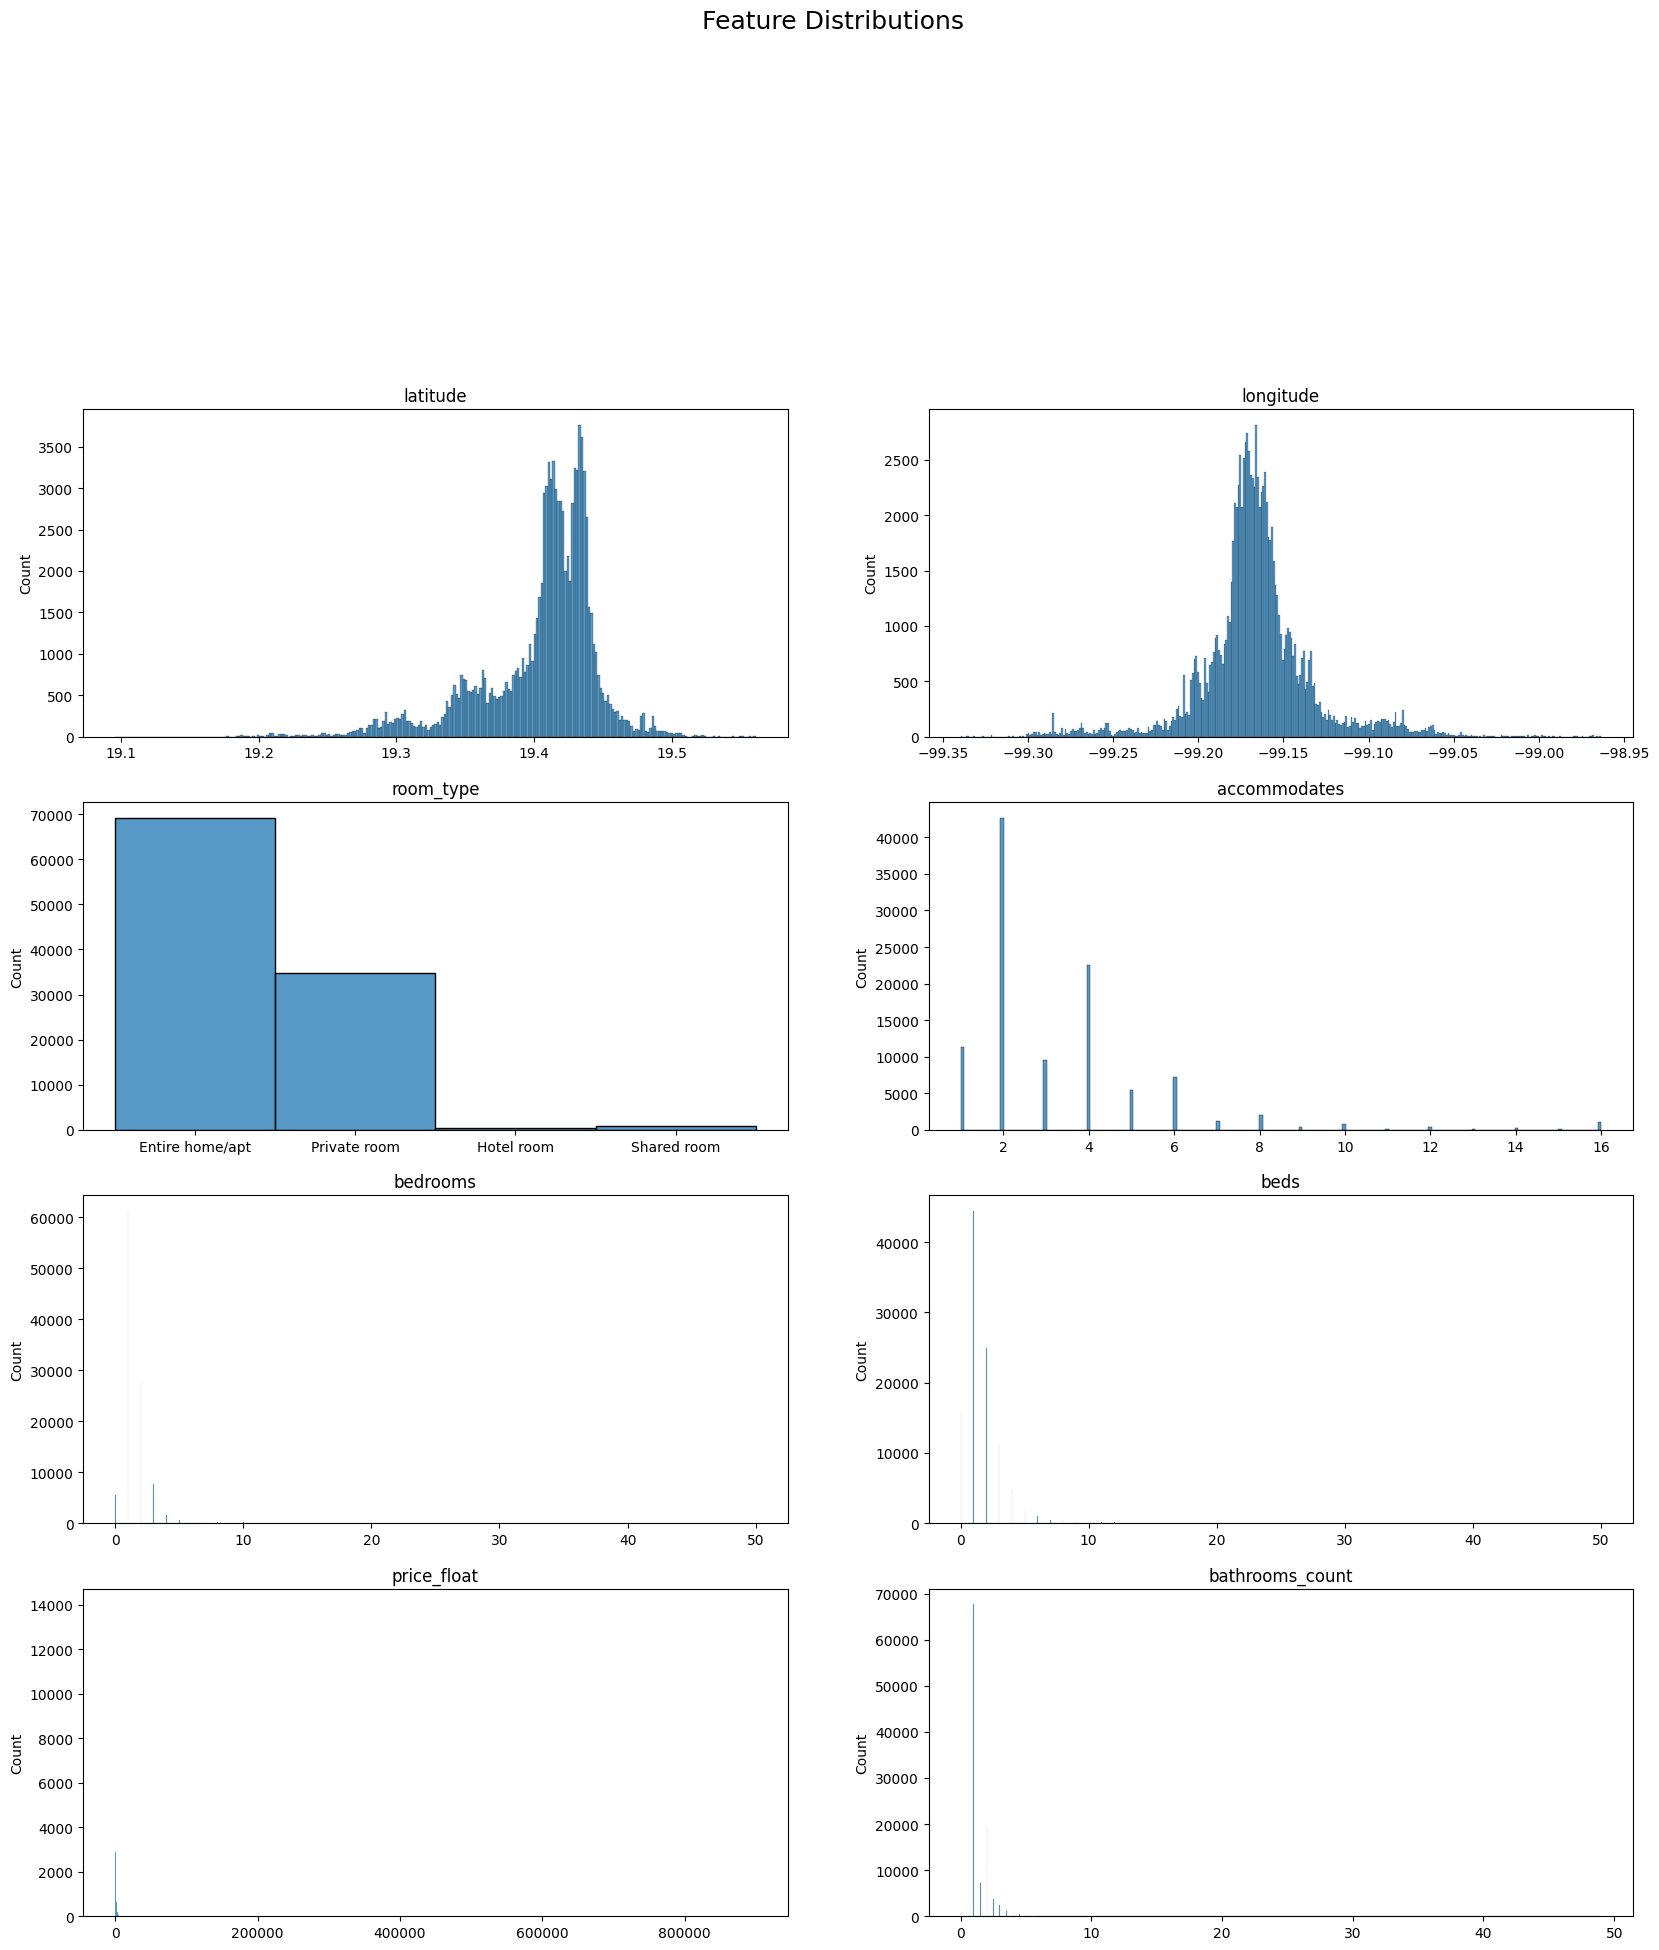

In [ ]:
#UNION
def plot_distributions(data):
    nums = data.select_dtypes(include=np.number)
    rows = len(data.columns)

    plt.figure(figsize=(20, 40))
    plt.suptitle("Feature Distributions", fontsize=18)
    for n, feature in enumerate(data.columns):
        ax = plt.subplot(rows, 2, n+1)
        sns.histplot(data=data, x=feature, ax=ax)

        ax.set_title(feature)
        ax.set_xlabel("")
    plt.show()
    pass

plot_distributions(data.drop(columns='id'))

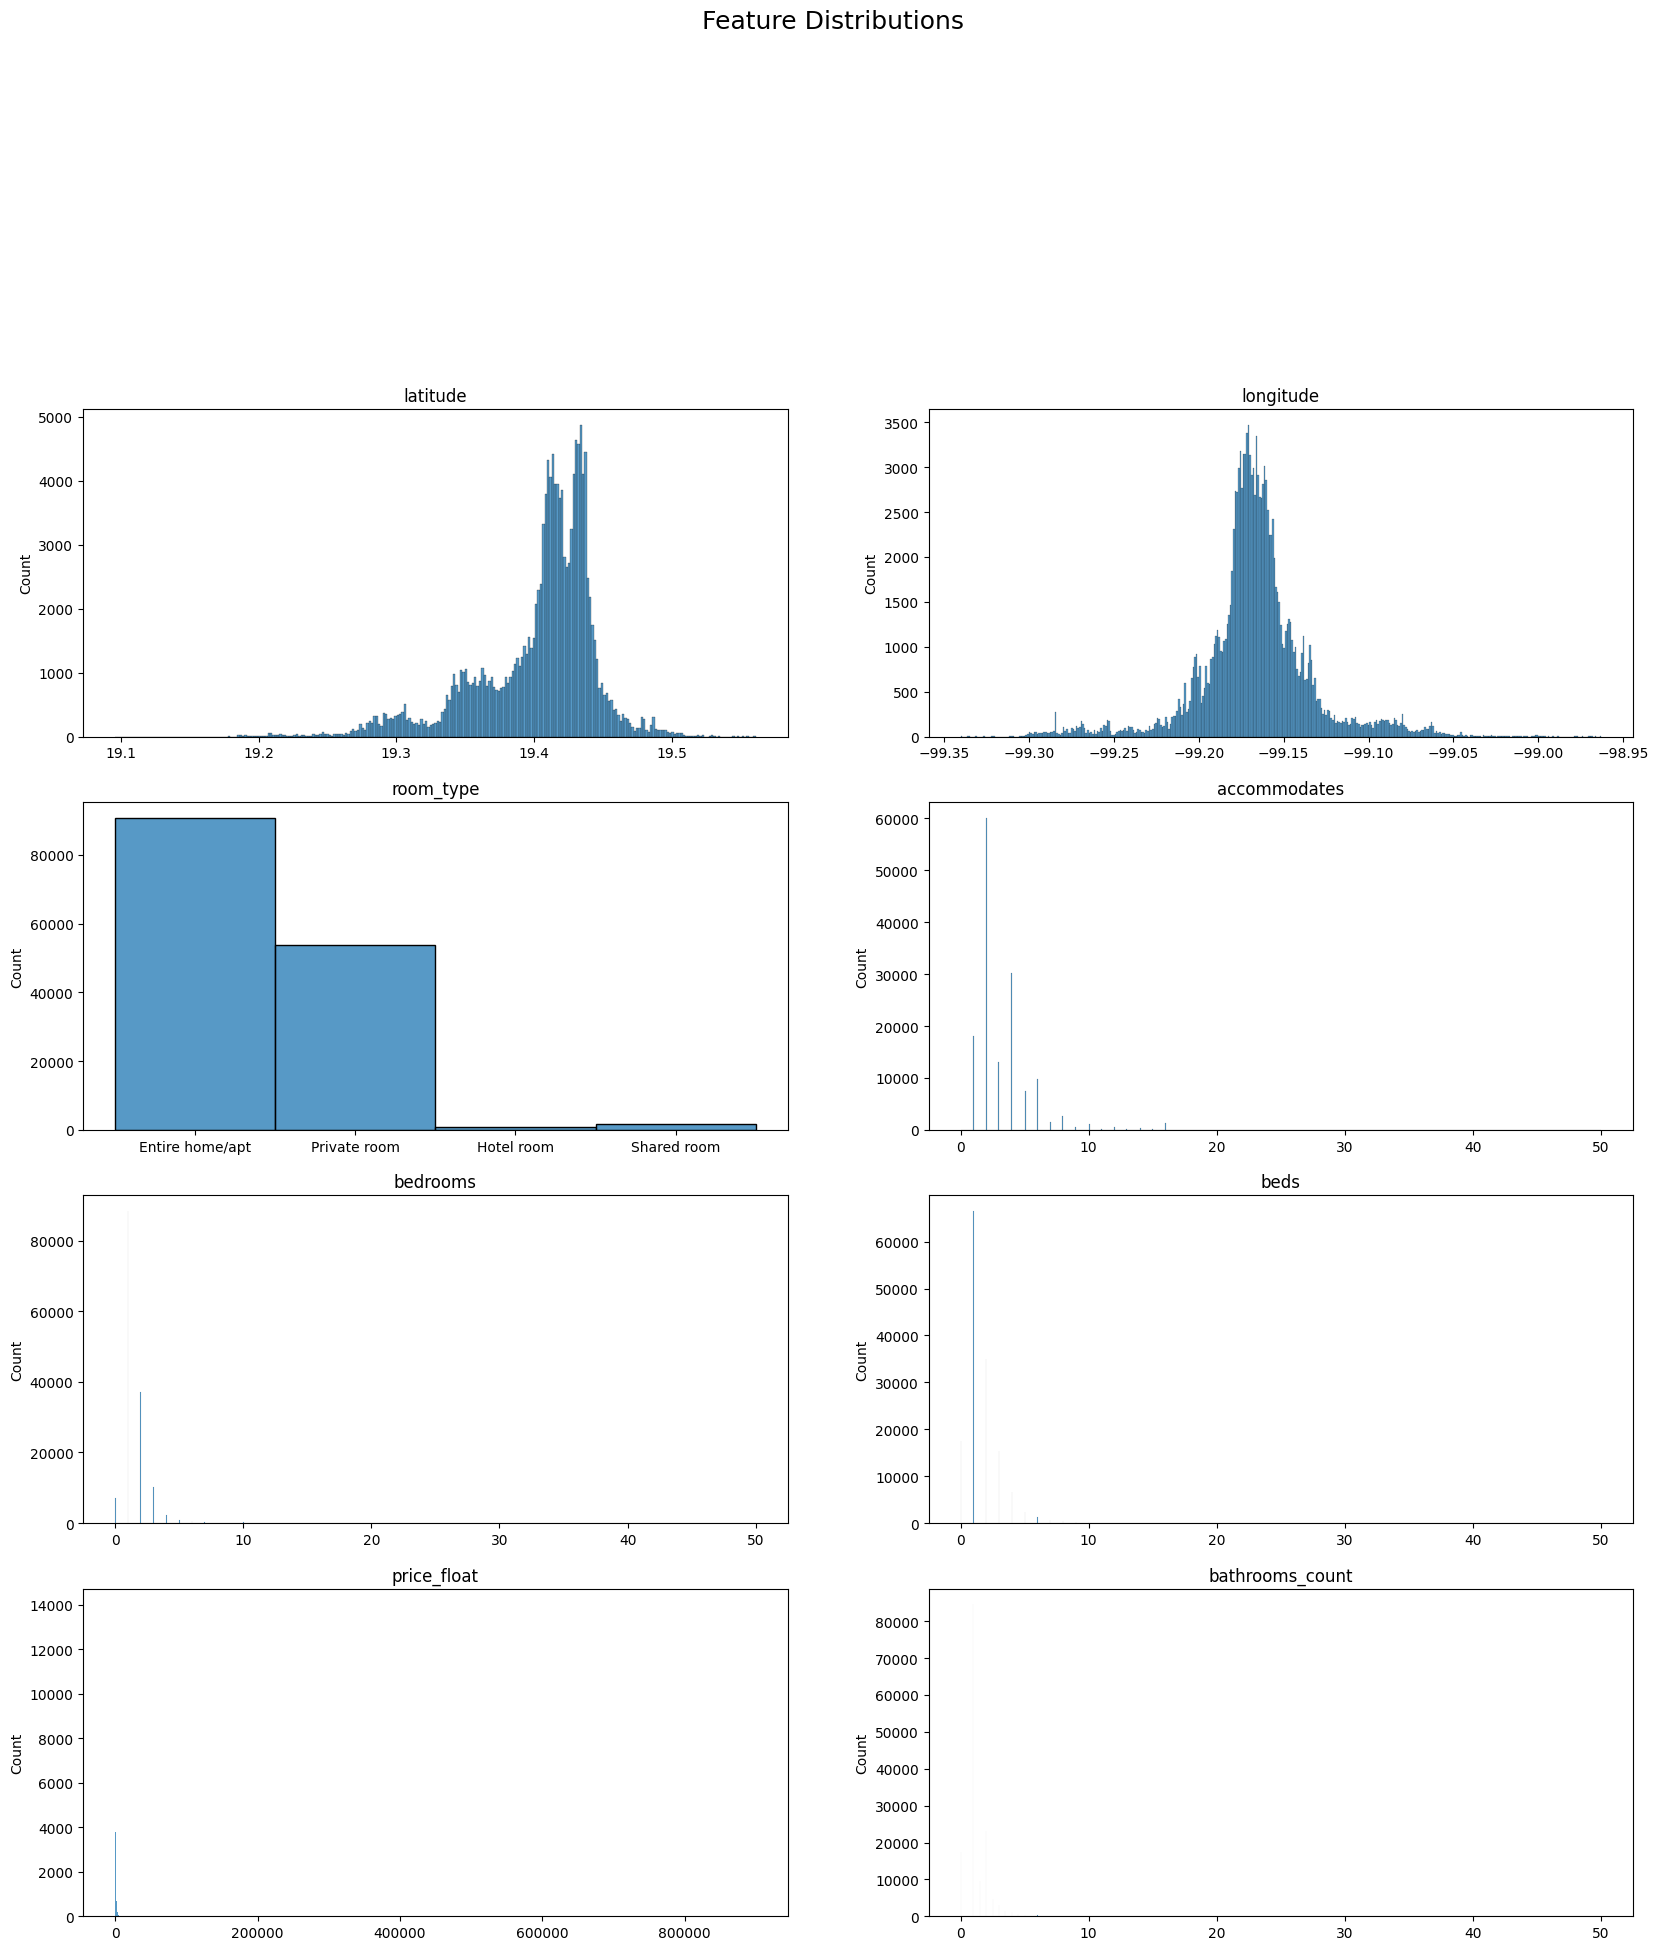

In [ ]:
#UNION_GZ
def plot_distributions(data):
    nums = data.select_dtypes(include=np.number)
    rows = len(data.columns)

    plt.figure(figsize=(20, 40))
    plt.suptitle("Feature Distributions", fontsize=18)
    for n, feature in enumerate(data.columns):
        ax = plt.subplot(rows, 2, n+1)
        sns.histplot(data=data, x=feature, ax=ax)

        ax.set_title(feature)
        ax.set_xlabel("")
    plt.show()
    pass

plot_distributions(data.drop(columns='id'))

In [ ]:
#UNION_18C
def plot_distributions(data):
    nums = data.select_dtypes(include=np.number)
    rows = len(data.columns)

    plt.figure(figsize=(20, 40))
    plt.suptitle("Feature Distributions", fontsize=18)
    for n, feature in enumerate(data.columns):
        ax = plt.subplot(rows, 2, n+1)
        sns.histplot(data=data, x=feature, ax=ax)

        ax.set_title(feature)
        ax.set_xlabel("")
    plt.show()
    pass

plot_distributions(data.drop(columns='id'))

In [ ]:
def iqr(data, feature_list):
  upper_bounds = {}
  for feature in feature_list:
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = (q3 - q1)*1.5
    upper_bounds[feature] = q3 + iqr

  return upper_bounds

In [ ]:
outliers = ['bedrooms', 'beds', 'bathrooms_count', 'price_float']
iqrs = iqr(data, outliers)

In [ ]:
# Drop Outliers
for feature in outliers:
  data = data[data[feature] < iqrs[feature]]

In [ ]:
#UNION
print(f"Rows dropped: {initial_len - len(data)}")

Rows dropped: 15669


In [ ]:
#UNION_GZ
print(f"Rows dropped: {initial_len - len(data)}")

Rows dropped: 25783


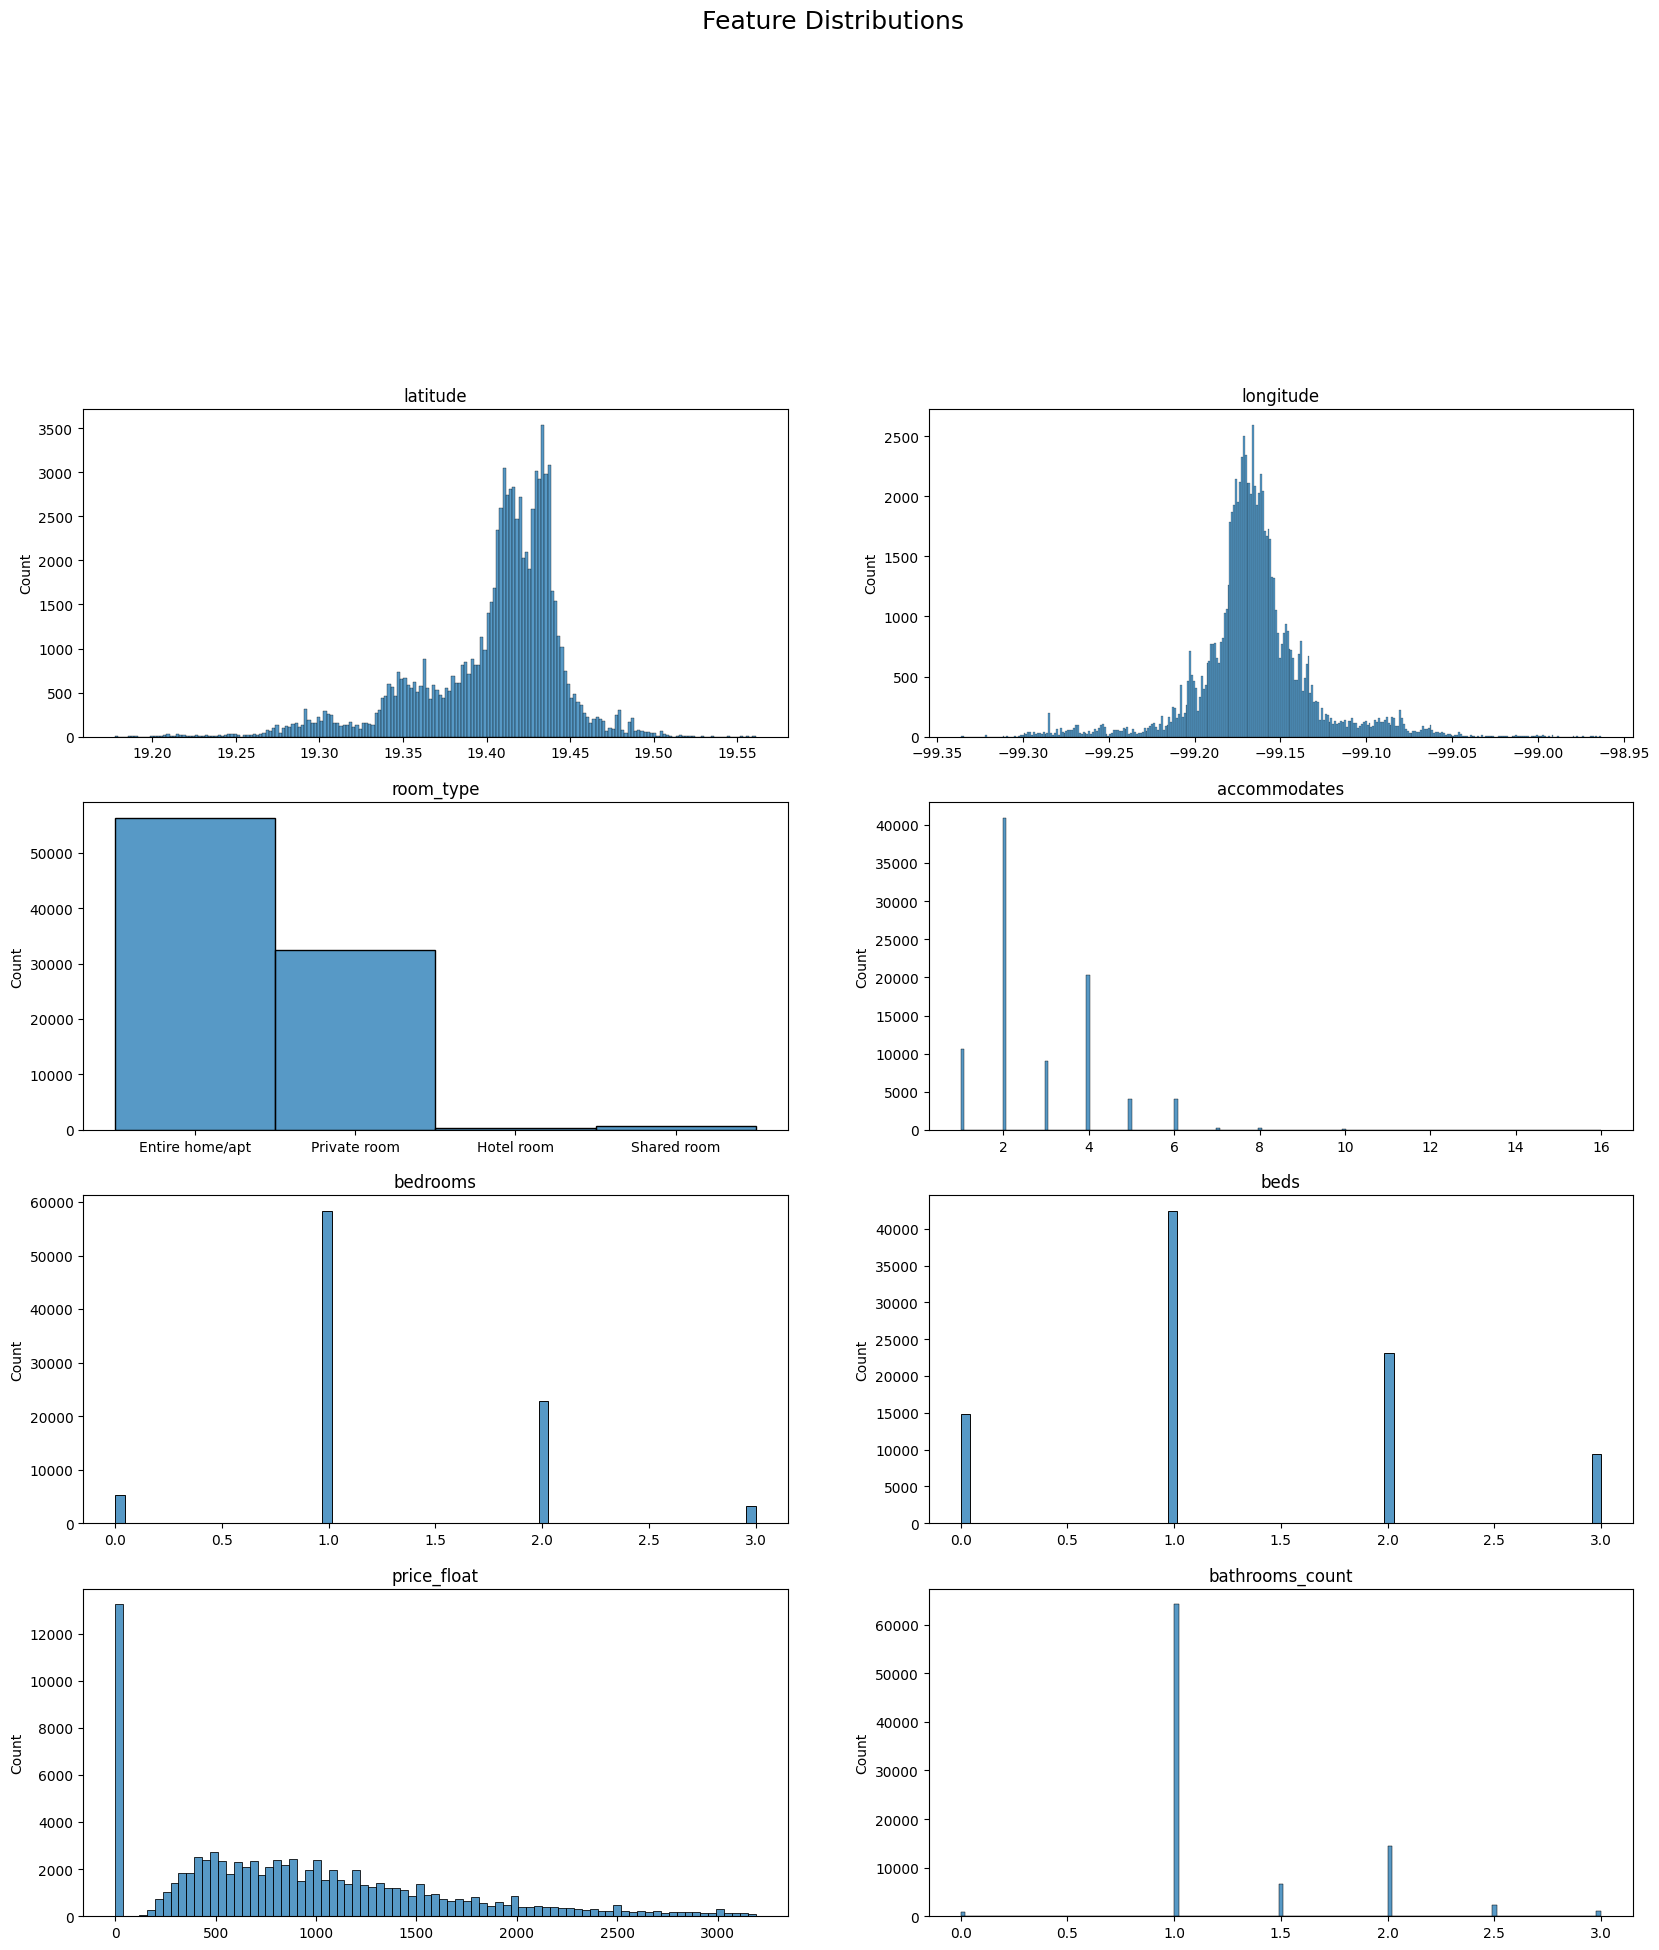

In [ ]:
plot_distributions(data.drop(columns='id'))

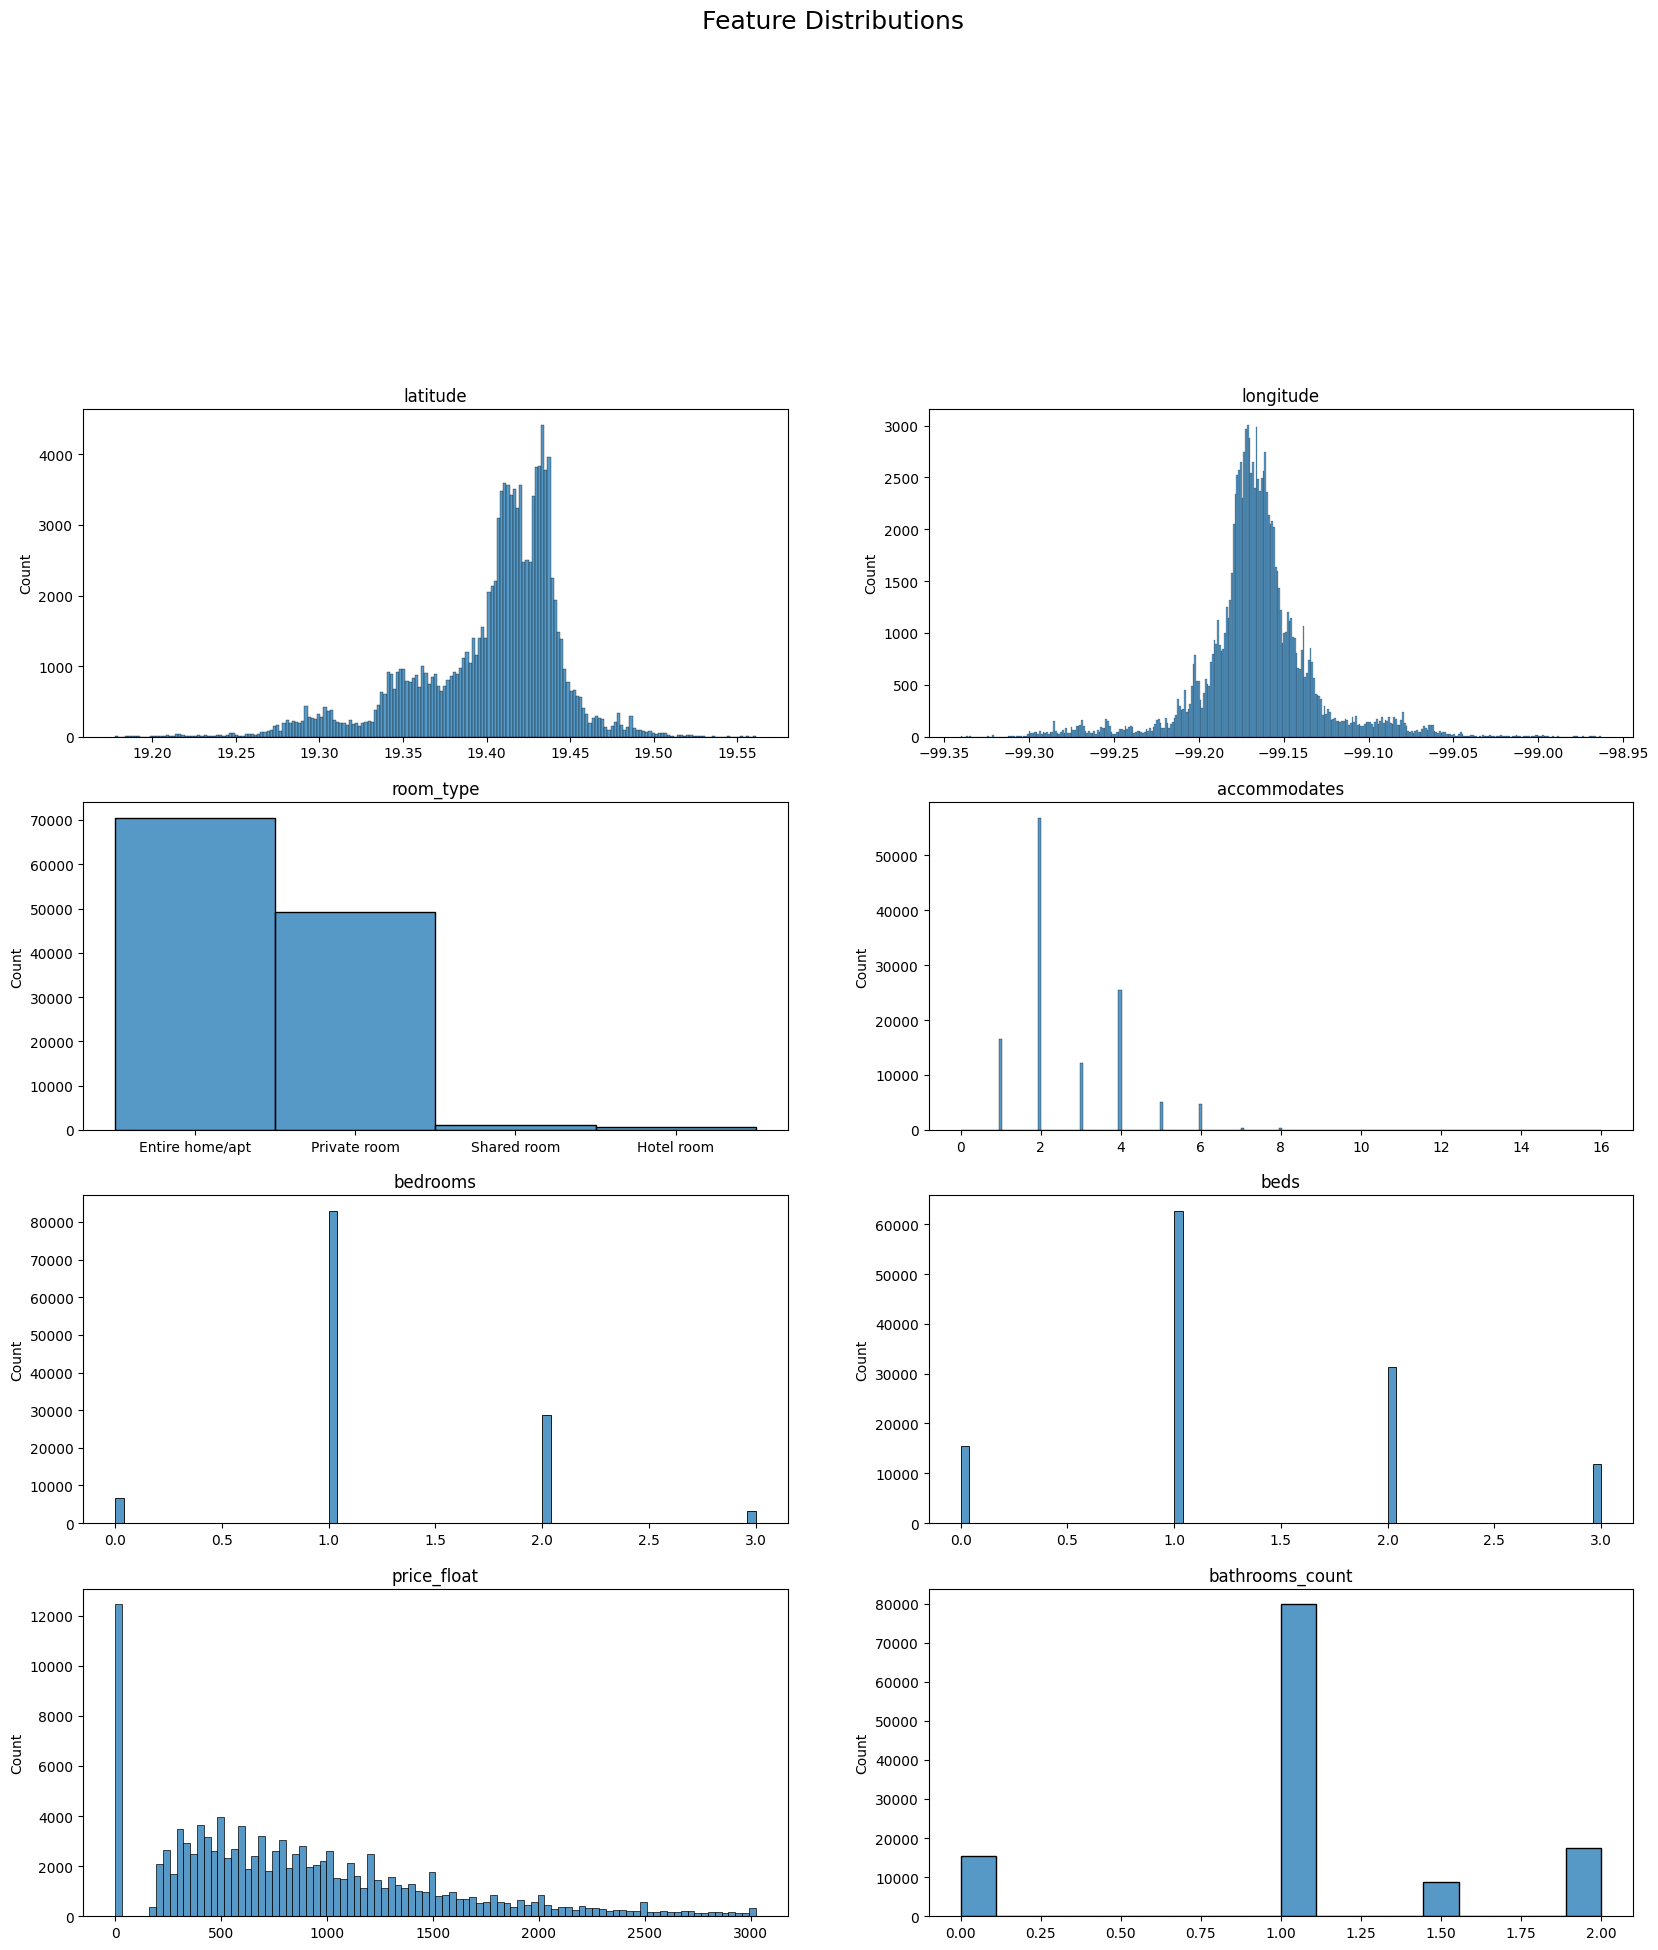

In [ ]:
#UNION_GZ
plot_distributions(data.drop(columns='id'))

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121437 entries, 1 to 147218
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               121437 non-null  int64  
 1   latitude         121437 non-null  float64
 2   longitude        121437 non-null  float64
 3   room_type        121437 non-null  object 
 4   accommodates     121437 non-null  int64  
 5   bedrooms         121437 non-null  float64
 6   beds             121437 non-null  float64
 7   price_float      121437 non-null  float64
 8   bathrooms_count  121437 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 9.3+ MB


## Clusters

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.compose import make_column_selector
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

ct = make_column_transformer(
    (
        StandardScaler(),
        [
            "latitude",
            "longitude",
            "accommodates",
            "bedrooms",
            "beds",
            "price_float",
            "bathrooms_count",
        ],
    ),
    (OneHotEncoder(), ["room_type"]),
    remainder="passthrough",
)

In [ ]:
X = ct.fit_transform(data.drop(columns='id'))

In [ ]:
kmeans = KMeans(n_clusters=43, random_state=12)
kmeans.fit(X)

# dbscan = DBSCAN(eps=1, min_samples=50, n_jobs=-1)
# dbscan.fit(X)

k_sil_score = silhouette_score(X, kmeans.labels_)
# db_sil_score = silhouette_score(X, dbscan.labels_)


print(k_sil_score)

#0.19165063590854745 UNION

0.18970294017671024


In [ ]:
data['cluster'] = kmeans.labels_

In [ ]:
!pip install descartes

In [ ]:
import geopandas as gpd
import descartes
from shapely.geometry import Point, Polygon

<Axes: >

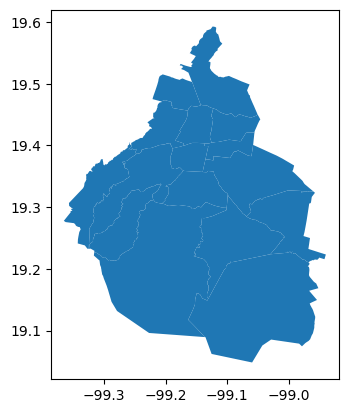

In [ ]:
import os
os.environ["SHAPE_RESTORE_SHX"] = "YES"
cdmx = gpd.read_file('/content/drive/MyDrive/GENTRIFICACION 2025/DATOS AIRBNB /BASE M/poligonos_alcaldias_cdmx.shp')
cdmx.plot()

In [ ]:
cdmx.head()

,geometry
0,"POLYGON ((-99.18231 19.50748, -99.18229 19.507..."
1,"POLYGON ((-99.13427 19.35654, -99.13397 19.356..."
2,"POLYGON ((-99.25738 19.40112, -99.25698 19.400..."
3,"POLYGON ((-99.11124 19.5615, -99.11485 19.5576..."
4,"POLYGON ((-99.05751 19.40673, -99.05753 19.406..."


In [ ]:
cdmx.head()

,cvegeo,cve_ent,cve_mun,nomgeo,geometry
0,09002,09,002,Azcapotzalco,"POLYGON ((-99.18231 19.50748, -99.18229 19.507..."
1,09006,09,006,Iztacalco,"POLYGON ((-99.05584 19.42196, -99.05589 19.421..."
2,09009,09,009,Milpa Alta,"POLYGON ((-98.99723 19.22731, -98.99745 19.227..."
3,09010,09,010,Álvaro Obregón,"POLYGON ((-99.18871 19.39475, -99.18868 19.394..."
4,09013,09,013,Xochimilco,"POLYGON ((-99.09870 19.31964, -99.09849 19.319..."


In [ ]:
crs = {'init': 'epsg:4326'}
geometry = [Point(xy) for xy in zip(data['longitude'], data['latitude'])]

In [ ]:
crs = {'init': 'epsg:4326'}
geometry = [Point(xy) for xy in zip(data['longitude'], data['latitude'])]

In [ ]:
geo_df = gpd.GeoDataFrame(data, crs=crs, geometry=geometry)
geo_df.head()

/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,id,latitude,longitude,room_type,accommodates,bedrooms,beds,price_float,bathrooms_count,cluster,geometry
1,56074,19.43937,-99.15614,Entire home/apt,3,1.0,2.0,843.0,0.0,27,POINT (-99.15614 19.43937)
2,61792,19.41259,-99.17959,Private room,2,1.0,1.0,1359.0,0.0,4,POINT (-99.17959 19.41259)
3,70644,19.35601,-99.16167,Entire home/apt,2,1.0,1.0,1245.0,0.0,27,POINT (-99.16167 19.35601)
5,131610,19.35266,-99.16338,Private room,2,1.0,1.0,1857.0,0.0,16,POINT (-99.16338 19.35266)
7,171109,19.39549,-99.17616,Private room,2,1.0,0.0,296.0,0.0,4,POINT (-99.17616 19.39549)


In [ ]:
geo_df = gpd.GeoDataFrame(data, crs=crs, geometry=geometry)
geo_df.head()

/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,id,latitude,longitude,room_type,accommodates,bedrooms,beds,price_float,bathrooms_count,cluster,geometry
2,67703,19.41152,-99.16857,Entire home/apt,4,2.0,2.0,2029.0,1.0,7,POINT (-99.16857 19.41152)
3,70644,19.35614,-99.16308,Entire home/apt,2,1.0,1.0,1140.0,1.0,12,POINT (-99.16308 19.35614)
5,131610,19.35416,-99.16488,Private room,2,2.0,0.0,0.0,1.0,2,POINT (-99.16488 19.35416)
7,171109,19.39675,-99.17581,Private room,2,1.0,1.0,335.0,1.0,25,POINT (-99.17581 19.39675)
8,1001517,19.34610,-99.15911,Entire home/apt,6,2.0,0.0,0.0,2.5,23,POINT (-99.15911 19.3461)


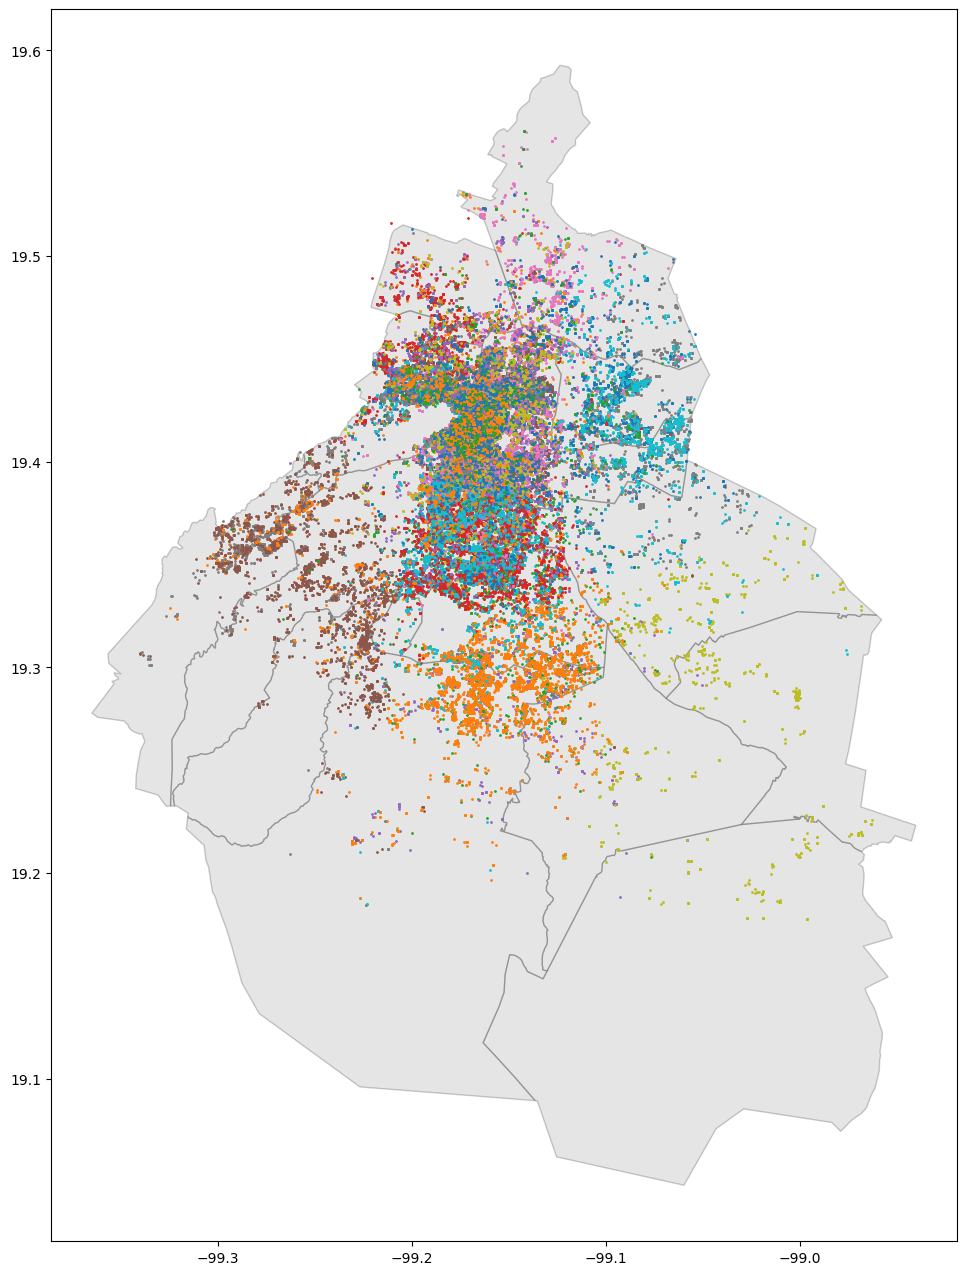

In [ ]:

fig, ax = plt.subplots(figsize=(40,16))
cdmx.plot(ax=ax, alpha=.2, color='grey', edgecolor='black', legend=True)
for cluster in geo_df['cluster'].unique():
    geo_df[geo_df['cluster'] == cluster].plot(ax=ax, markersize=1)


In [ ]:
clustered = pd.merge(
    left=data,
    right=df[
        [
            "id",
            "availability_30",
            "availability_60",
            "availability_90",
            "availability_365",
        ]
    ],
    how="left",
    on="id",
)

In [ ]:
clustered

,id,latitude,longitude,room_type,accommodates,bedrooms,beds,price_float,bathrooms_count,cluster,availability_30,availability_60,availability_90,availability_365
0,56074,19.439370,-99.156140,Entire home/apt,3,1.0,2.0,843.0,0.0,27,0,0,0,0
1,56074,19.439370,-99.156140,Entire home/apt,3,1.0,2.0,843.0,0.0,27,10,40,70,345
2,56074,19.439370,-99.156140,Entire home/apt,3,1.0,2.0,843.0,0.0,27,26,56,86,361
3,56074,19.439370,-99.156140,Entire home/apt,3,1.0,2.0,843.0,0.0,27,3,33,63,338
4,61792,19.412590,-99.179590,Private room,2,1.0,1.0,1359.0,0.0,4,30,60,90,180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463000,1450249880192776928,19.414804,-99.142905,Private room,2,1.0,1.0,351.0,1.0,23,0,11,20,200
463001,1450299137475327273,19.490670,-99.174150,Entire home/apt,6,2.0,3.0,1080.0,1.0,42,29,57,84,359
463002,1450300528106131951,19.391438,-99.181881,Entire home/apt,2,1.0,1.0,982.0,1.0,2,29,59,89,364
463003,1450345027980478127,19.419767,-99.175294,Entire home/apt,4,2.0,2.0,1612.0,1.0,3,29,59,89,364


In [ ]:
ct2 = make_column_transformer(
    (
        StandardScaler(),
        [
            "latitude",
            "longitude",
        ],
    ),
    remainder="passthrough",
)

In [ ]:
X2 = ct2.fit_transform(data[['latitude', 'longitude']])

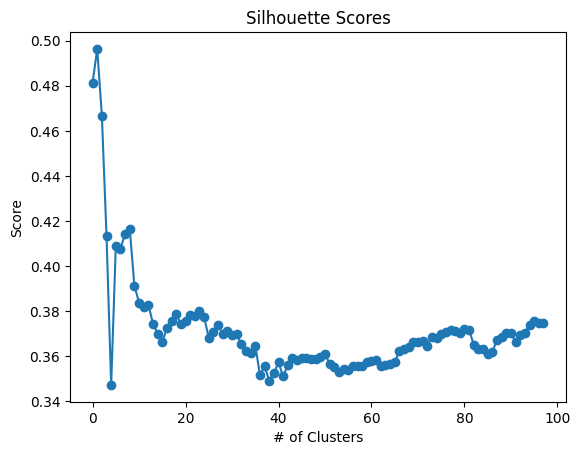

In [ ]:
silhouette_list = []

for k in range(2, 100):
    kmeans = KMeans(n_clusters=k, random_state=12)
    kmeans.fit(X2)
    silhouette_list.append(silhouette_score(X2, kmeans.labels_))

plt.plot(silhouette_list, marker='o')
plt.xlabel('# of Clusters')
plt.ylabel('Score')
plt.title('Silhouette Scores');

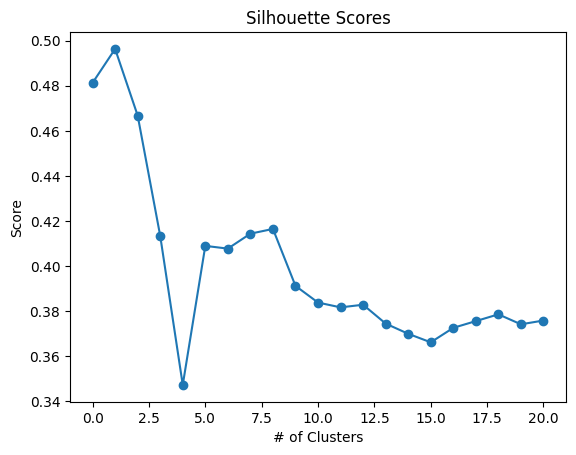

In [ ]:
plt.plot(silhouette_list[:21], marker='o')
plt.xlabel('# of Clusters')
plt.ylabel('Score')
plt.title('Silhouette Scores');

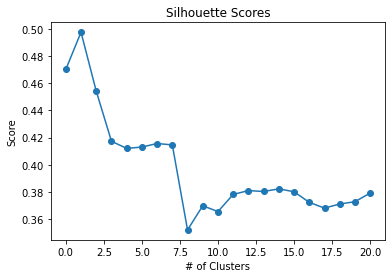

In [ ]:
plt.plot(silhouette_list[:21], marker='o')
plt.xlabel('# of Clusters')
plt.ylabel('Score')
plt.title('Silhouette Scores');

In [ ]:
kmeans2 = KMeans(n_clusters=7, random_state=12)
kmeans2.fit(X2)

KMeans(n_clusters=7, random_state=12)

In [ ]:
data['cluster2'] = kmeans2.labels_

In [ ]:
geo_df = gpd.GeoDataFrame(data, crs=crs, geometry=geometry)
geo_df.head()

/usr/local/lib/python3.12/dist-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,id,latitude,longitude,room_type,accommodates,bedrooms,beds,price_float,bathrooms_count,cluster,cluster2,geometry
1,56074,19.43937,-99.15614,Entire home/apt,3,1.0,2.0,843.0,0.0,27,0,POINT (-99.15614 19.43937)
2,61792,19.41259,-99.17959,Private room,2,1.0,1.0,1359.0,0.0,4,5,POINT (-99.17959 19.41259)
3,70644,19.35601,-99.16167,Entire home/apt,2,1.0,1.0,1245.0,0.0,27,1,POINT (-99.16167 19.35601)
5,131610,19.35266,-99.16338,Private room,2,1.0,1.0,1857.0,0.0,16,1,POINT (-99.16338 19.35266)
7,171109,19.39549,-99.17616,Private room,2,1.0,0.0,296.0,0.0,4,5,POINT (-99.17616 19.39549)


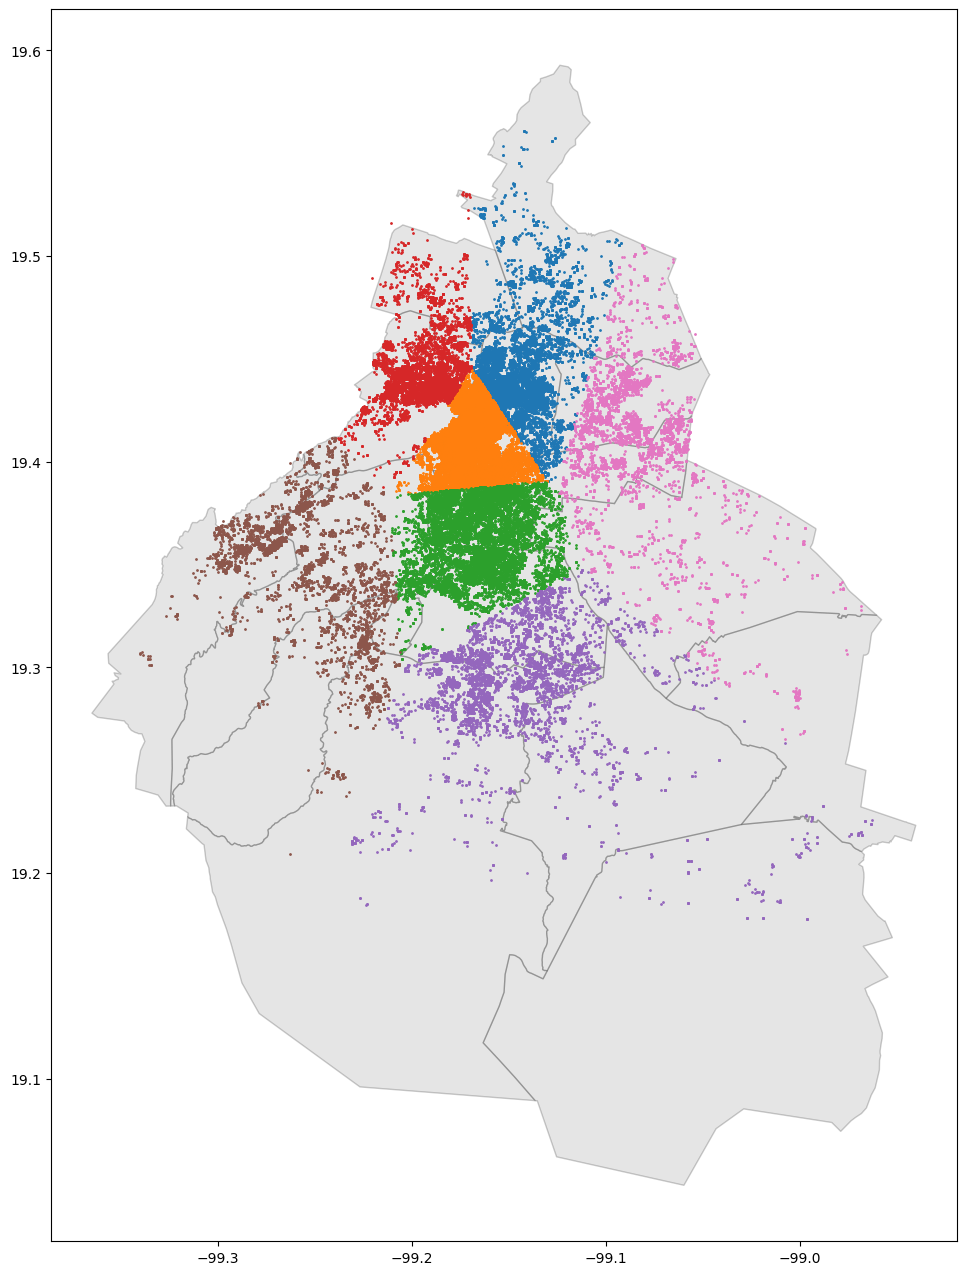

In [ ]:

fig, ax = plt.subplots(figsize=(40,16))
cdmx.plot(ax=ax, alpha=.2, color='grey', edgecolor='black', legend=True)
for cluster in geo_df['cluster2'].unique():
    geo_df[geo_df['cluster2'] == cluster].plot(ax=ax, markersize=1)
